In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_theme()

In [3]:
features = ['SchoolType', 'Locale', 'InternetAccess', 'SES_Quartile']
target = 'GPA'

In [4]:
train = pd.read_csv('archive/train.csv')
validation = pd.read_csv('archive/validation.csv')
test = pd.read_csv('archive/test.csv')


In [5]:
train_x= train[features]
train_y = train[target]
val_x = validation[features]
val_y = validation[target]
test_x = test[features]
test_y = test[target]

In [15]:
le_dict = {}
for feature in features:
    le = LabelEncoder()
    le_dict[feature] = le
    train_x[feature] = le.fit_transform(train_x[feature])
    val_x[feature] = le.transform(val_x[feature])
    test_x[feature] = le.transform(test_x[feature])

In [7]:
terms = (
    s(0) +  # SchoolType
    s(1) +  # Locale
    s(2) +  # InternetAccess
    s(3)    # SES_Quartile
)

gam = LinearGAM(terms)

lams = np.logspace(-3, 3, 11)
gam.gridsearch(train_x.values, train_y.values, lam=lams)

y_pred_train = gam.predict(train_x.values)
y_pred_val = gam.predict(val_x.values)
y_pred_test = gam.predict(test_x.values)



  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:05:04 ETA:   0:50:42
 18% (2 of 11) |####                     | Elapsed Time: 0:09:30 ETA:   0:42:46
 27% (3 of 11) |######                   | Elapsed Time: 0:13:53 ETA:   0:37:03
 36% (4 of 11) |#########                | Elapsed Time: 0:16:51 ETA:   0:29:30
 45% (5 of 11) |###########              | Elapsed Time: 0:19:46 ETA:   0:23:44
 54% (6 of 11) |#############            | Elapsed Time: 0:22:48 ETA:   0:19:00
 63% (7 of 11) |###############          | Elapsed Time: 0:25:39 ETA:   0:14:39
 72% (8 of 11) |##################       | Elapsed Time: 0:28:51 ETA:   0:10:49
 81% (9 of 11) |####################     | Elapsed Time: 0:32:11 ETA:   0:07:09
 90% (10 of 11) |#####################   | Elapsed Time: 0:35:11 ETA:   0:03:31
100% (11 of 11) |########################| Elapsed Time: 0:38:02 Time:  0:38:02


In [8]:
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance on {dataset_name} dataset:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate model performance
evaluate_model(train_y, y_pred_train, "Training")
evaluate_model(val_y, y_pred_val, "Validation")
evaluate_model(test_y, y_pred_test, "Test")


Performance on Training dataset:
MSE: 0.2112
RMSE: 0.4595
R² Score: 0.0000

Performance on Validation dataset:
MSE: 0.2115
RMSE: 0.4599
R² Score: -0.0000

Performance on Test dataset:
MSE: 0.2111
RMSE: 0.4595
R² Score: -0.0000


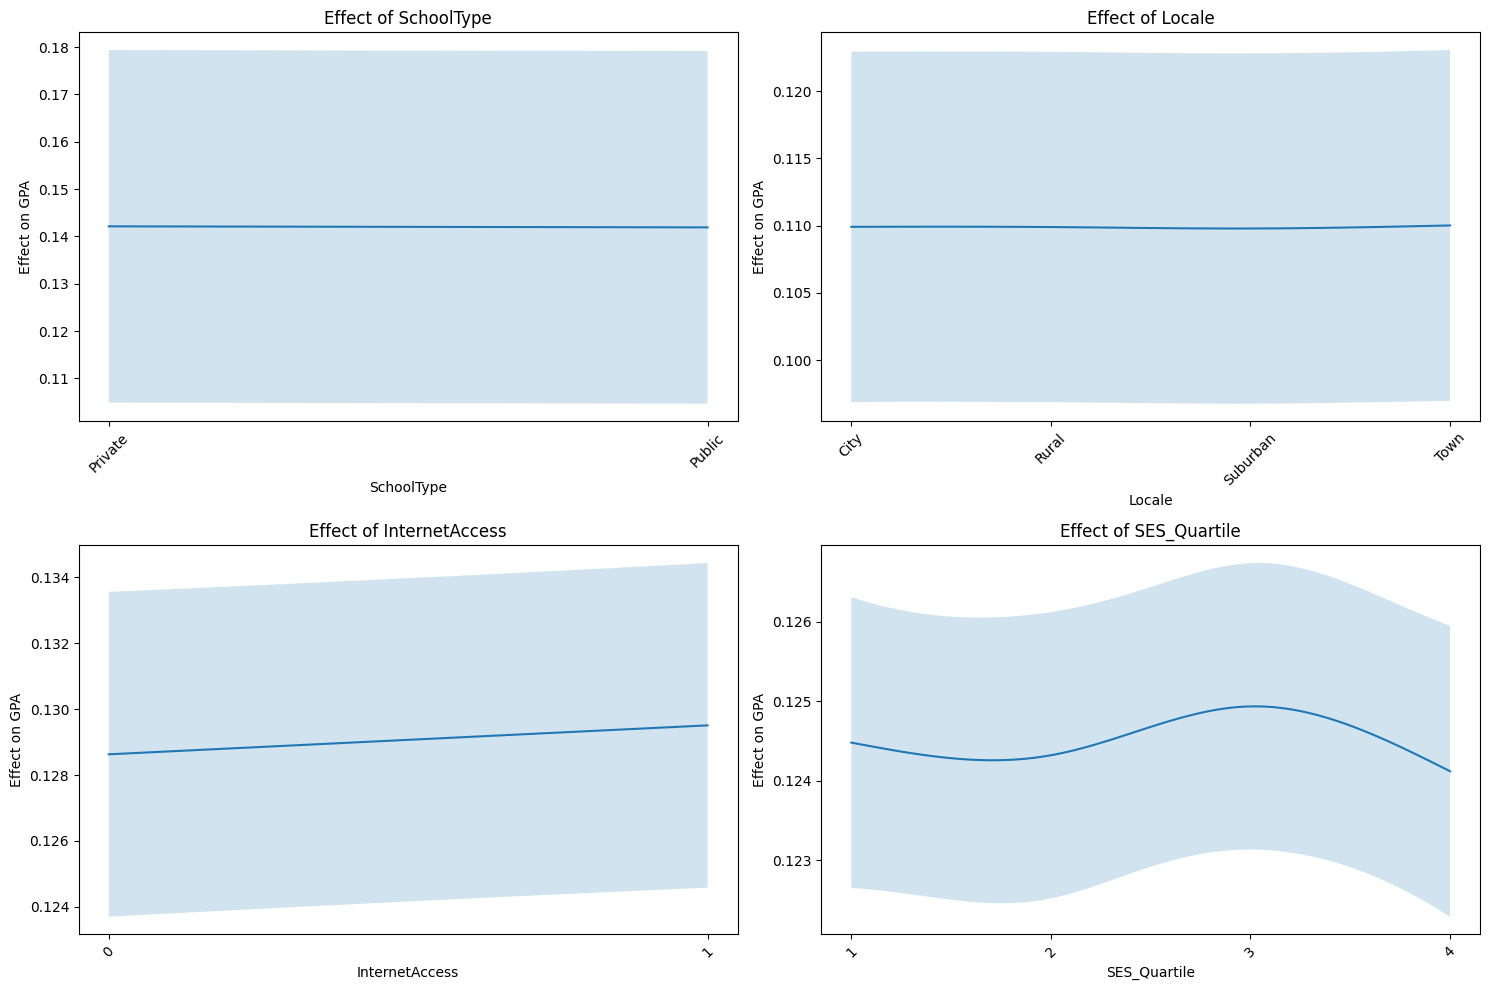

In [9]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    
    plt.plot(XX[:, i], pdep)
    plt.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2)
    plt.title(f'Effect of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Effect on GPA')
    
    if feature in le_dict:
        le = le_dict[feature]
        plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)

plt.tight_layout()
plt.show()

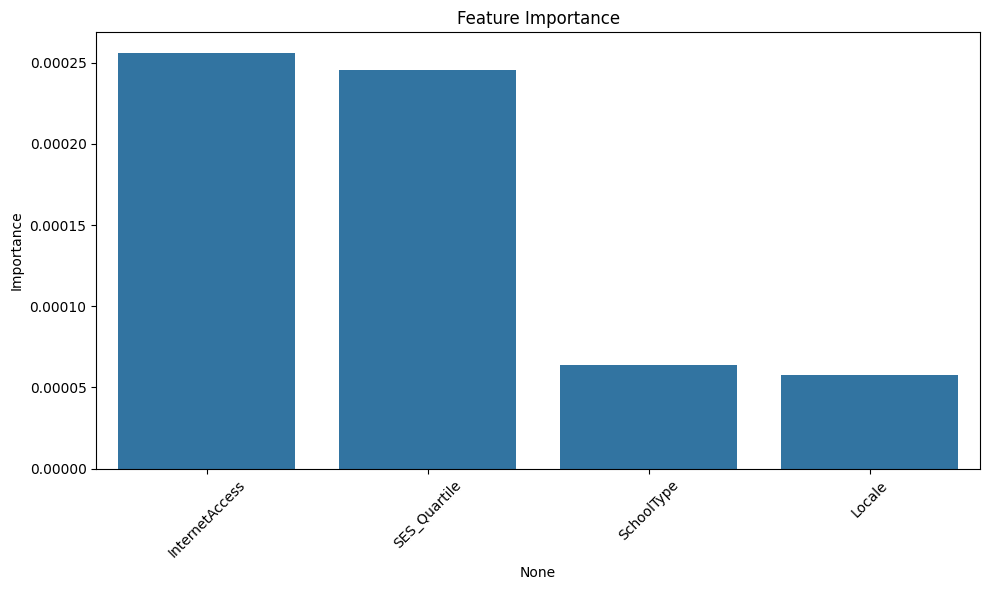

In [ ]:
importance = {}
for i, feature in enumerate(features):
    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)
    importance[feature] = np.std(pdep)

plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame.from_dict(importance, orient='index', columns=['Importance'])
importance_df = importance_df.sort_values('Importance', ascending=False)
sns.barplot(x=importance_df.index, y='Importance', data=importance_df)
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [12]:
print("\n=== Final Analysis Results ===")
print("\nFeature Importance:")
print(importance_df)


=== Final Analysis Results ===

Feature Importance:
                Importance
InternetAccess    0.000256
SES_Quartile      0.000245
SchoolType        0.000064
Locale            0.000058
